A script to plot cross sections of the gap topography

In [54]:
import numpy as np
import scipy
from netCDF4 import Dataset
import matplotlib
from matplotlib import pyplot as plt
import cartopy
import cartopy.crs as ccrs

In [55]:
savefig = True

# Use the SE simulation data
dycore = 'CAM-SE'
res = 'se_ne60'
test_name_start = 'cam_6_4_100'
lev_no = 'ztop20km_L57'
extra_name = 'tau_1_10'

case = f'{test_name_start}_{res}_{lev_no}'
nc_omega0 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name}.nc'
nc_rot = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name}.nc'

In [56]:
run_base = "/glade/derecho/scratch/timand/"

run_path_omega0 = run_base + case + '/run/' + nc_omega0
run_path_rot = run_base + case + '/run/' + nc_rot

nc_omega0 = Dataset(run_path_omega0)
nc_rot = Dataset(run_path_rot)

time = nc_omega0['time'][:]
lat = nc_omega0['lat'][:] 
lon = nc_omega0['lon'][:] 
lev = nc_omega0['lev'][:]

print(f'{len(lat)} latitiude points, {len(lon)} longitude points')

LON, LAT = np.meshgrid(lon, lat)
LAT_RAD = LAT*np.pi/180

361 latitiude points, 720 longitude points


In [57]:
# Extract the surface pressure information
ps_omega0 = nc_omega0['PS'][0]
ps_rot = nc_rot['PS'][0]

ps_omega0_hPa = ps_omega0/100
ps_rot_hPa = ps_rot/100

lon_vals = [0, 60, 120, 180, 240, 300, 360]
lon_vals_rob = [-180, -120, -60, 0, 60, 120, 180]
lat_vals = [-90, -60, -30, 0, 30, 60, 90]

[ 82000.  84000.  86000.  88000.  90000.  92000.  94000.  96000.  98000.
 100000. 102000. 104000. 106000.]
saving file to figures/gap_surf_p.jpg


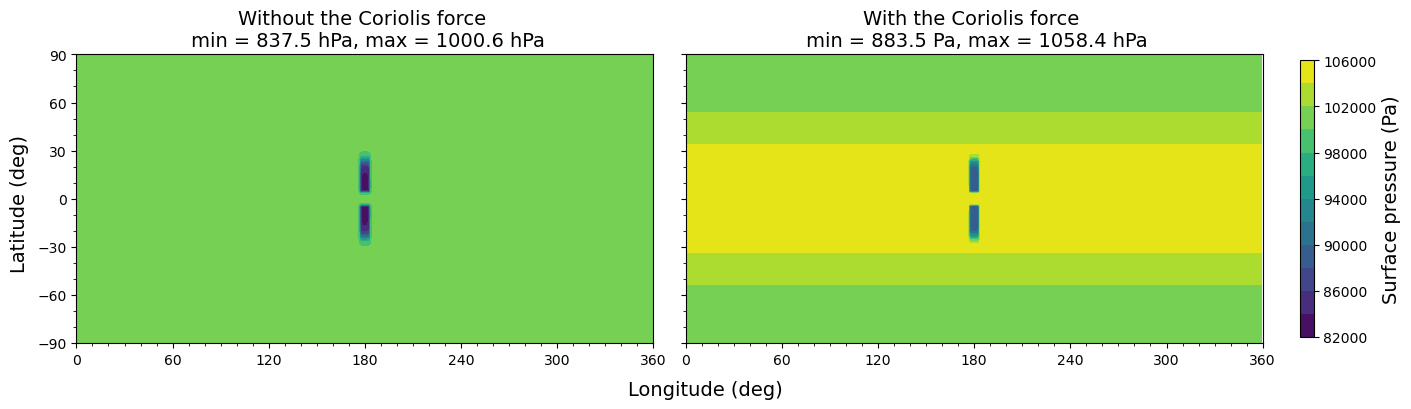

In [61]:
fig, axes = plt.subplots(1,2, figsize=(14,4),constrained_layout=True, sharey=True)
ax1, ax2 = axes

conts = np.linspace(82000, 106000, 13)
cbar_ticks = np.linspace(82000, 106000, 7)
print(conts)

plot1 = ax1.contourf(LON, LAT, ps_omega0, levels=conts)
ax1.set_title(f'Without the Coriolis force \n min = {np.min(ps_omega0_hPa):.1f} hPa, max = {np.max(ps_omega0_hPa):.1f} hPa', size=14)

plot2 = ax2.contourf(LON, LAT, ps_rot, levels=conts)
ax2.set_title(f'With the Coriolis force \n min = {np.min(ps_rot_hPa):.1f} Pa, max = {np.max(ps_rot_hPa):.1f} hPa', size=14)

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(10))
    
    ax.set_aspect('equal')
    ax.set_aspect('equal')
    
    ax.set_xticks(lon_vals)
    ax.set_yticks(lat_vals)

fig.supylabel('Latitude (deg)', size=14)
fig.supxlabel('Longitude (deg)', size=14)

cb = plt.colorbar(plot2, ax=axes, ticks=cbar_ticks, shrink=0.8, pad=0.02)
cb.set_label(label=r"Surface pressure (Pa)", size=14)

base_savename = f'gap_surf_p.jpg'

save_name = f'figures/{base_savename}'

print(f'saving file to {save_name}')
if savefig:
    plt.savefig(save_name)

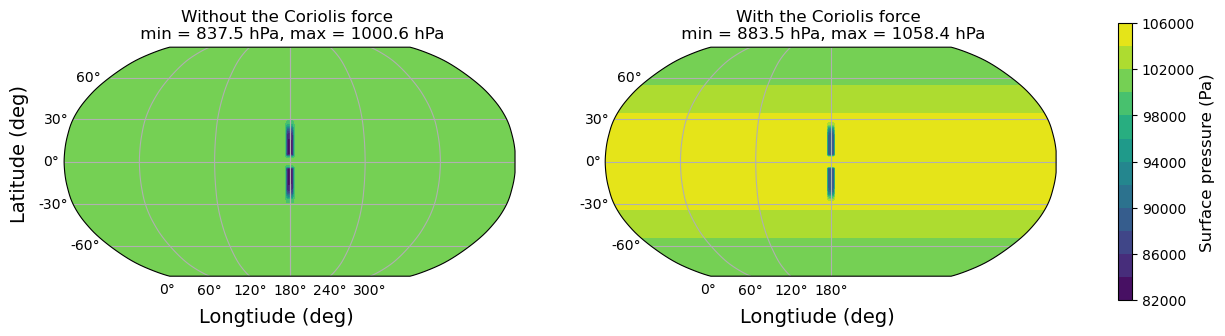

In [59]:
# Plot with Robinson projection:

# Make a common colorbar
conts = np.linspace(82000, 106000, 13)
cbar_ticks = conts

fig, axes = plt.subplots(1,2, figsize=(16,4), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)})
ax1, ax2 = axes

plot1 = ax1.contourf(LON, LAT, ps_omega0, levels=conts, transform=ccrs.PlateCarree())
plot2 = ax2.contourf(LON, LAT, ps_rot, levels=conts, transform=ccrs.PlateCarree())

ax1.set_title(f'Without the Coriolis force \n min = {np.min(ps_omega0_hPa):.1f} hPa, max = {np.max(ps_omega0_hPa):.1f} hPa')
ax2.set_title(f'With the Coriolis force \n min = {np.min(ps_rot_hPa):.1f} hPa, max = {np.max(ps_rot_hPa):.1f} hPa')

ax1.text(-1.32,0.25, 'Latitude (deg)',
         rotation='vertical', transform=plt.gca().transAxes, fontsize=14)
ax1.text(-0.9, -0.2, 'Longtiude (deg)', transform=plt.gca().transAxes, fontsize=14)
ax2.text(0.3, -0.2, 'Longtiude (deg)', transform=plt.gca().transAxes, fontsize=14)

cb = plt.colorbar(plot2, ax=axes, shrink=0.9, pad=0.05)
cb.set_label(label=r"Surface pressure (Pa)", size=12)

gl1 = ax1.gridlines(draw_labels=True, crs=ccrs.PlateCarree())
gl1.top_labels = False    # Turn off top labels
gl1.right_labels = False  # Turn off right labels
gl1.xformatter = matplotlib.ticker.FuncFormatter(lambda x, pos: f"{(x + 360) % 360:.0f}°")
gl1.yformatter = matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x:.0f}°")

gl2 = ax2.gridlines(draw_labels=True, crs=ccrs.PlateCarree())
gl2.top_labels = False    # Turn off top labels
gl2.right_labels = False  # Turn off right labels
gl2.xlocator = matplotlib.ticker.FixedLocator(lon_vals)
gl2.ylocator = matplotlib.ticker.FixedLocator(lat_vals)
gl2.xformatter = matplotlib.ticker.FuncFormatter(lambda x, pos: f"{(x + 360) % 360:.0f}°")
gl2.yformatter = matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x:.0f}°")

if savefig:
    plt.savefig('figures/gap_ps_robinson.png', bbox_inches='tight')

0.0006023415329590455
0.05657148187396415


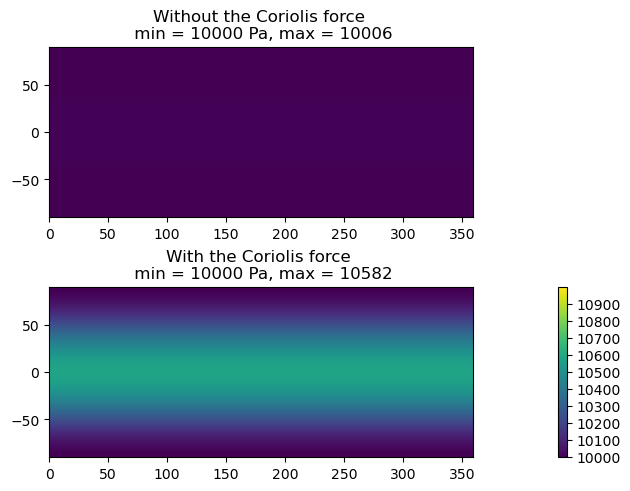

In [60]:
# What do we expect from theory?
p_sp = 10000
X = 20
rearth = 6371229/X
N2 = 0.0182**2
u0 = 10
gravit = 9.81
cappa = 2/7
omega = 20*7.2921e-5



tmp1_0 = (rearth * N2 * u0)/(2*cappa*(gravit**2))*(u0/rearth)
tmp1_rot = (rearth * N2 * u0)/(2*cappa*(gravit**2))*(u0/rearth + 2*omega)

print(tmp1_0)
print(tmp1_rot)

tmp2 = N2/((gravit**2)*cappa)

surf_h = 0*LAT_RAD

ps_omega0_analyt = p_sp*np.exp(-tmp1_0*((np.sin(LAT_RAD))**2 - 1) - tmp2*gravit*surf_h)
ps_rot_analyt = p_sp*np.exp(-tmp1_rot*((np.sin(LAT_RAD))**2 - 1) - tmp2*gravit*surf_h)

conts = np.arange(10000, 11000)

fig, axes = plt.subplots(2,1,constrained_layout=True)
ax1, ax2 = axes

plot1 = ax1.contourf(LON, LAT, ps_omega0_analyt, levels=conts)
plot2 = ax2.contourf(LON, LAT, ps_rot_analyt, levels=conts)

ax1.set_title(f'Without the Coriolis force \n min = {np.min(ps_omega0_analyt):.0f} Pa, max = {np.max(ps_omega0_analyt):.0f}')
ax2.set_title(f'With the Coriolis force \n min = {np.min(ps_rot_analyt):.0f} Pa, max = {np.max(ps_rot_analyt):.0f}')


plt.colorbar(plot2, ax=ax2, shrink=1.0, pad=0.2)
